# Avaliação e Validação de Modelos — FIAP Pós Tech IA para Devs (Fase 3)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vagner-nascimento/fiap-pos-ia-para-devs-fase3-tech-challenge/blob/main/backend/src/notebooks/FIAP_PosTech_IA4Devs_Fase3_TechChallenge_AvaliacaoModelos.ipynb)

## Visão Geral do Notebook
Este notebook é dedicado à **avaliação formal e análise quantitativa e qualitativa** do modelo "fine-tunado" para o assistente médico hospitalar (`hospital-helper`), atendendo ao requisito do edital do Tech Challenge Fase 3.

### Estágios dos Modelos Avaliados:
1. **Modelo Base Fundacional:** `Qwen/Qwen2.5-1.5B-Instruct` (sem fine-tuning no domínio hospitalar brasileiro).
2. **Fine-Tuned v1.0 (Tag `v1.0`):** Treinado no notebook `v1` com 188 steps de aquecimento.
3. **Fine-Tuned v2.0 (Tag `v2.0` - Produção):** Treinado a partir do notebook `v2` (evoluído até o `v4`) com checkpoints contínuos e consolidados no Hugging Face Hub.

### Métricas Computadas:
- **ROUGE-1, ROUGE-2 e ROUGE-L** (precisão, recall e f-measure)
- **BLEU-4** (precisão de n-gramas em relação às respostas de referência clínica)
- **Latência e Throughput** (tempo de inferência e tokens por segundo na GPU T4)
- **Análise Qualitativa Lado a Lado (*Side-by-Side*):** Comparação clínica de condutas de emergência e ativação de guardrails assistenciais.

## 1. Verificação do Ambiente de Execução e GPU

In [1]:
!nvidia-smi

import torch
print(f"CUDA disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Dispositivo GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM Total: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
    print(f"Suporte a bfloat16: {torch.cuda.is_bf16_supported()}")

Sun Sep  6 13:25:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Instalação das Dependências de Avaliação

In [2]:
# Instalação silenciosa de pacotes para inferência e cálculo de métricas NLP
!pip install -q transformers accelerate evaluate rouge-score sacrebleu tabulate matplotlib sentencepiece

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 14.6 MB/s eta 0:00:00


## 3. Configuração de Parâmetros e Seleção de Tags no Hugging Face

### Teste com 3 configurações diferentes:

---

Configuração A — Greedy Determinística (Padrão de Precisão Clínica)
```
TEMPERATURE = 0.0
DO_SAMPLE = False
MAX_NEW_TOKENS = 300
REPETITION_PENALTY = 1.05
```

---

Configuração B — Baixa Entropia com Amostragem Suave (Mais Natural)
```
TEMPERATURE = 0.15
TOP_P = 0.90
DO_SAMPLE = True
MAX_NEW_TOKENS = 300
REPETITION_PENALTY = 1.10

```

---
Configuração C — Respostas Extensas / Ricas em Explicação


```
TEMPERATURE = 0.10
TOP_P = 0.85
DO_SAMPLE = False
MAX_NEW_TOKENS = 450
REPETITION_PENALTY = 1.10

```




### Avaliação do modelo usando a **Configuraçao A**

In [3]:
#@title Parâmetros de Avaliação do Modelo

# Identificador do repositório no Hugging Face Hub
HF_MODEL_REPO = "fiap-hospital-helper/hospital-helper-qwen2.5-1.5b" #@param {type:"string"}

# Tag de revisão a ser avaliada no Hugging Face Hub (ex: 'v2.0', 'v1.0' ou 'main')
HF_MODEL_TAG = "v2.0" #@param ["v2.0", "v1.0", "main"]

# Modelo fundacional base para comparação ('antes vs depois')
BASE_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct" #@param {type:"string"}

# Se True, executa inferência sequencial no Base e no Fine-Tuned para gerar o delta de melhoria
RUN_COMPARATIVE = True #@param {type:"boolean"}

# Hiperparâmetros de geração e decodificação
MAX_NEW_TOKENS = 300 #@param {type:"integer"}
DO_SAMPLE = False #@param {type:"boolean"}
TEMPERATURE = 0.0 #@param {type:"number"}
TOP_P = 0.9 #@param {type:"number"}
REPETITION_PENALTY = 1.05 #@param {type:"number"}

print(f"[Config] Repositório HF: {HF_MODEL_REPO}")
print(f"[Config] Tag selecionada: {HF_MODEL_TAG}")
print(f"[Config] Modelo Base de comparação: {BASE_MODEL_NAME}")
print(f"[Config] Modo Comparativo: {RUN_COMPARATIVE}")
print(f"[Config] Geração: max_new_tokens={MAX_NEW_TOKENS}, do_sample={DO_SAMPLE}, temp={TEMPERATURE}, top_p={TOP_P}, repetition_penalty={REPETITION_PENALTY}")

[Config] Repositório HF: fiap-hospital-helper/hospital-helper-qwen2.5-1.5b
[Config] Tag selecionada: v2.0
[Config] Modelo Base de comparação: Qwen/Qwen2.5-1.5B-Instruct
[Config] Modo Comparativo: True
[Config] Geração: max_new_tokens=300, do_sample=False, temp=0.0, top_p=0.9, repetition_penalty=1.05


## 4. Carregamento do Conjunto de Teste (Golden Test QA)
O conjunto de teste foi curado com 50 casos médicos balanceados em língua portuguesa:
- **15 casos de Protocolos Clínicos e Diretrizes Terapêuticas (PCDT / SUS / FHEMIG):** Casos de emergência (dor torácica, sepse, CAD, AVC, anafilaxia, IC) e guardrails de segurança.
- **35 casos clínicos de PubMedQA e MedQuAD (pt-BR):** Diversas especialidades médicas para validação de generalização.

In [4]:
import json
import os
import requests
from pathlib import Path

LOCAL_DATASET_PATH = Path("golden_test_qa.json")
GITHUB_RAW_URL = "https://raw.githubusercontent.com/vagner-nascimento/fiap-pos-ia-para-devs-fase3-tech-challenge/main/backend/datasets/evaluation/golden_test_qa.json"

if LOCAL_DATASET_PATH.exists():
    print(f"Carregando dataset de teste do arquivo local: {LOCAL_DATASET_PATH}")
    with open(LOCAL_DATASET_PATH, "r", encoding="utf-8") as f:
        golden_test_set = json.load(f)
else:
    print(f"Baixando dataset de teste do repositório oficial no GitHub...")
    resp = requests.get(GITHUB_RAW_URL, timeout=30)
    if resp.status_code == 200:
        golden_test_set = resp.json()
        with open(LOCAL_DATASET_PATH, "w", encoding="utf-8") as f:
            json.dump(golden_test_set, f, indent=2, ensure_ascii=False)
        print("Download concluído com sucesso!")
    else:
        raise RuntimeError(f"Falha ao baixar dataset de teste (HTTP {resp.status_code})")

print(f"Total de amostras de teste carregadas: {len(golden_test_set)}")
protocols = [x for x in golden_test_set if x.get('category') == 'clinical_protocol']
qas = [x for x in golden_test_set if x.get('category') != 'clinical_protocol']
print(f"  - Protocolos Clínicos (SUS/FHEMIG): {len(protocols)}")
print(f"  - Casos Clínicos Gerais (PubMedQA/MedQuAD pt-BR): {len(qas)}")

Carregando dataset de teste do arquivo local: golden_test_qa.json
Total de amostras de teste carregadas: 50
  - Protocolos Clínicos (SUS/FHEMIG): 14
  - Casos Clínicos Gerais (PubMedQA/MedQuAD pt-BR): 36


## 5. Função de Carregamento Modular de Modelos com Tags
A função abaixo instancia o tokenizer e o modelo causal diretamente da GPU, aceitando o parâmetro `revision` para especificar qualquer tag ou branch do repositório Hugging Face.

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import gc

def load_model_and_tokenizer(model_id: str, revision: str = None):
    """
    Carrega o modelo e tokenizer em bfloat16 na GPU alocada pelo Colab.
    Permite selecionar a revisão/tag exata do Hugging Face Hub.
    """
    tag_str = f" (revision={revision})" if revision else " (versão default/main)"
    print(f"--> Carregando {model_id}{tag_str} na GPU...")

    tokenizer = AutoTokenizer.from_pretrained(model_id, revision=revision, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        revision=revision,
        torch_dtype=dtype,
        device_map="auto"
    )
    model.eval()
    print(f"✓ Modelo carregado com sucesso! VRAM utilizada: {torch.cuda.memory_allocated(0)/(1024**3):.2f} GB")
    return model, tokenizer

def free_gpu_memory(model, tokenizer):
    """Desaloca o modelo da memória de vídeo e força coleta de lixo."""
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print(f"✓ Memória de GPU liberada! VRAM alocada: {torch.cuda.memory_allocated(0)/(1024**3):.2f} GB")

## 6. Pipeline de Inferência em Lote
A formatação do prompt utiliza a estrutura instrucional padrão adotada durante o fine-tuning:
```text
### Instrucao:
Responda em pt-BR usando o contexto clinico fornecido.

### Entrada:
Contexto: {contexto}
Pergunta: {pergunta}

### Resposta:
```

In [6]:
import time
from tqdm.auto import tqdm

def build_instruction_prompt(question: str, context: str) -> str:
    return (
        "### Instrucao:\n"
        "Responda em pt-BR usando o contexto clinico fornecido.\n\n"
        f"### Entrada:\nContexto: {context}\nPergunta: {question}\n\n"
        "### Resposta:\n"
    )

def run_inference_batch(model, tokenizer, test_items, max_new_tokens=250, desc="Inferência"):
    predictions = []
    total_time = 0.0
    total_tokens = 0

    for item in tqdm(test_items, desc=desc):
        prompt = build_instruction_prompt(item["question"], item.get("context", ""))
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        input_len = inputs["input_ids"].shape[1]

        t0 = time.perf_counter()
        gen_kwargs = {
            "max_new_tokens": max_new_tokens,
            "pad_token_id": tokenizer.eos_token_id,
            "repetition_penalty": REPETITION_PENALTY,
            "do_sample": DO_SAMPLE,
        }
        if DO_SAMPLE:
            gen_kwargs["temperature"] = TEMPERATURE
            gen_kwargs["top_p"] = TOP_P

        with torch.no_grad():
            outputs = model.generate(**inputs, **gen_kwargs)
        elapsed = time.perf_counter() - t0

        generated_tokens = outputs[0][input_len:]
        response_text = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

        total_time += elapsed
        total_tokens += len(generated_tokens)
        predictions.append(response_text)

    stats = {
        "total_time_seconds": total_time,
        "avg_latency_per_sample": total_time / len(test_items),
        "tokens_per_second": total_tokens / total_time if total_time > 0 else 0
    }
    return predictions, stats

## 7. Execução da Inferência Comparativa (Base vs Fine-Tuned)
Para garantir que a GPU T4 opere com folga de memória e sem risco de estouro de VRAM (*Out of Memory*), executamos sequencialmente:
1. Carregamos o **Modelo Base** -> inferência no conjunto de teste -> liberação de GPU;
2. Carregamos o **Modelo Fine-Tuned** na tag selecionada -> inferência no conjunto de teste -> liberação de GPU.

In [7]:
base_predictions = []
base_stats = {}
ft_predictions = []
ft_stats = {}

if RUN_COMPARATIVE:
    print("=" * 60)
    print("FASE 1: Executando Inferência no Modelo Base")
    print("=" * 60)
    model_base, tok_base = load_model_and_tokenizer(BASE_MODEL_NAME)
    base_predictions, base_stats = run_inference_batch(
        model_base, tok_base, golden_test_set,
        max_new_tokens=MAX_NEW_TOKENS,
        desc=f"Inferência Base ({BASE_MODEL_NAME})"
    )
    free_gpu_memory(model_base, tok_base)

print("=" * 60)
print(f"FASE 2: Executando Inferência no Modelo Fine-Tuned ({HF_MODEL_TAG})")
print("=" * 60)
model_ft, tok_ft = load_model_and_tokenizer(HF_MODEL_REPO, revision=HF_MODEL_TAG)
ft_predictions, ft_stats = run_inference_batch(
    model_ft, tok_ft, golden_test_set,
    max_new_tokens=MAX_NEW_TOKENS,
    desc=f"Inferência FT ({HF_MODEL_TAG})"
)
free_gpu_memory(model_ft, tok_ft)

print("✓ Inferências concluídas para todas as amostras de teste!")

FASE 1: Executando Inferência no Modelo Base
--> Carregando Qwen/Qwen2.5-1.5B-Instruct (versão default/main) na GPU...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✓ Modelo carregado com sucesso! VRAM utilizada: 5.76 GB


Inferência FT (v2.0):   0%|          | 0/50 [00:00<?, ?it/s]

✓ Memória de GPU liberada! VRAM alocada: 5.76 GB
✓ Inferências concluídas para todas as amostras de teste!


## 8. Cálculo Automatizado de Métricas Quantitativas Formais
Computamos as métricas padrão de geração de texto clínico:
- **ROUGE-1:** Sobreposição de palavras isoladas (vocabulario e relevância de termos médicos);
- **ROUGE-2:** Sobreposição de bigramas (coesão e sintaxe médica de expressões clínicas compostas);
- **ROUGE-L:** Maior subsequência comum (preservação da estrutura da resposta de referência);
- **BLEU-4:** Precisão de n-gramas em relação às respostas padrão-ouro de médicos e diretrizes.

In [8]:
import evaluate
import pandas as pd
from tabulate import tabulate

rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("bleu")

references = [item["reference_answer"] for item in golden_test_set]

def compute_model_scores(predictions, references):
    rouge_res = rouge_metric.compute(predictions=predictions, references=references)

    # Para o BLEU, referências no formato de lista de listas
    bleu_refs = [[ref] for ref in references]
    bleu_res = bleu_metric.compute(predictions=predictions, references=bleu_refs)

    return {
        "ROUGE-1": rouge_res["rouge1"],
        "ROUGE-2": rouge_res["rouge2"],
        "ROUGE-L": rouge_res["rougeL"],
        "BLEU-4": bleu_res["bleu"]
    }

ft_scores = compute_model_scores(ft_predictions, references)

rows = []
if RUN_COMPARATIVE and len(base_predictions) == len(references):
    base_scores = compute_model_scores(base_predictions, references)
    rows.append([
        f"Base ({BASE_MODEL_NAME})",
        f"{base_scores['ROUGE-1']*100:.2f}%",
        f"{base_scores['ROUGE-2']*100:.2f}%",
        f"{base_scores['ROUGE-L']*100:.2f}%",
        f"{base_scores['BLEU-4']*100:.2f}%",
        f"{base_stats.get('avg_latency_per_sample', 0):.2f}s",
        f"{base_stats.get('tokens_per_second', 0):.1f} tok/s"
    ])

    # Calcular Delta
    d_r1 = ((ft_scores['ROUGE-1'] - base_scores['ROUGE-1']) / base_scores['ROUGE-1']) * 100
    d_r2 = ((ft_scores['ROUGE-2'] - base_scores['ROUGE-2']) / base_scores['ROUGE-2']) * 100
    d_rl = ((ft_scores['ROUGE-L'] - base_scores['ROUGE-L']) / base_scores['ROUGE-L']) * 100
    d_bl = ((ft_scores['BLEU-4'] - base_scores['BLEU-4']) / base_scores['BLEU-4']) * 100

rows.append([
    f"Fine-Tuned ({HF_MODEL_TAG})",
    f"{ft_scores['ROUGE-1']*100:.2f}%",
    f"{ft_scores['ROUGE-2']*100:.2f}%",
    f"{ft_scores['ROUGE-L']*100:.2f}%",
    f"{ft_scores['BLEU-4']*100:.2f}%",
    f"{ft_stats.get('avg_latency_per_sample', 0):.2f}s",
    f"{ft_stats.get('tokens_per_second', 0):.1f} tok/s"
])

if RUN_COMPARATIVE and len(base_predictions) == len(references):
    rows.append([
        "Δ Ganho Relativo (%)",
        f"+{d_r1:.1f}%",
        f"+{d_r2:.1f}%",
        f"+{d_rl:.1f}%",
        f"+{d_bl:.1f}%",
        "-",
        "-"
    ])

headers = ["Modelo / Versão", "ROUGE-1 (F1)", "ROUGE-2 (F1)", "ROUGE-L (F1)", "BLEU-4", "Latência Média", "Throughput"]
print("\n" + tabulate(rows, headers=headers, tablefmt="fancy_grid"))


╒═══════════════════════════════════╤════════════════╤════════════════╤════════════════╤══════════╤══════════════════╤══════════════╕
│ Modelo / Versão                   │ ROUGE-1 (F1)   │ ROUGE-2 (F1)   │ ROUGE-L (F1)   │ BLEU-4   │ Latência Média   │ Throughput   │
╞═══════════════════════════════════╪════════════════╪════════════════╪════════════════╪══════════╪══════════════════╪══════════════╡
│ Base (Qwen/Qwen2.5-1.5B-Instruct) │ 27.09%         │ 7.97%          │ 17.00%         │ 2.90%    │ 10.40s           │ 23.3 tok/s   │
├───────────────────────────────────┼────────────────┼────────────────┼────────────────┼──────────┼──────────────────┼──────────────┤
│ Fine-Tuned (v2.0)                 │ 24.30%         │ 7.13%          │ 18.52%         │ 2.11%    │ 5.77s            │ 23.8 tok/s   │
├───────────────────────────────────┼────────────────┼────────────────┼────────────────┼──────────┼──────────────────┼──────────────┤
│ Δ Ganho Relativo (%)              │ +-10.3%        │ +-10.6

## 9. Gráfico Comparativo das Métricas Formais

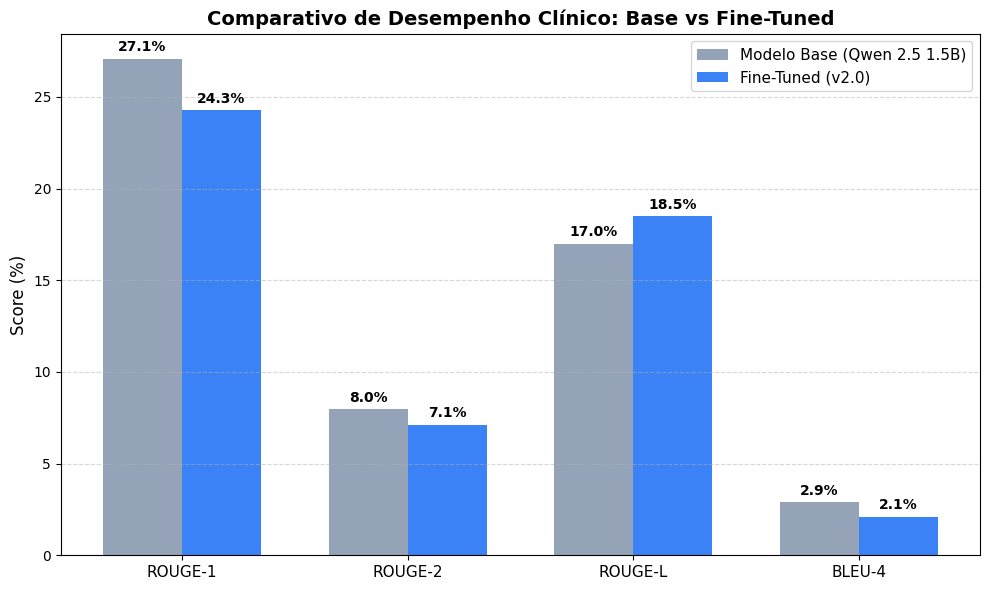

In [9]:
import matplotlib.pyplot as plt
import numpy as np

if RUN_COMPARATIVE and len(base_predictions) == len(references):
    metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU-4']
    base_vals = [base_scores['ROUGE-1']*100, base_scores['ROUGE-2']*100, base_scores['ROUGE-L']*100, base_scores['BLEU-4']*100]
    ft_vals = [ft_scores['ROUGE-1']*100, ft_scores['ROUGE-2']*100, ft_scores['ROUGE-L']*100, ft_scores['BLEU-4']*100]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, base_vals, width, label='Modelo Base (Qwen 2.5 1.5B)', color='#94a3b8')
    rects2 = ax.bar(x + width/2, ft_vals, width, label=f'Fine-Tuned ({HF_MODEL_TAG})', color='#3b82f6')

    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_title('Comparativo de Desempenho Clínico: Base vs Fine-Tuned', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)
    plt.tight_layout()
    plt.show()
else:
    print("Gráfico comparativo omitido (modo não comparativo ou inferência ausente).")

## 10. Inspeção Qualitativa Lado a Lado (*Side-by-Side*)
Apresentamos abaixo exemplos reais comparando as respostas de casos clínicos emblemáticos:
- **Aderência a protocolos do SUS / PCDT / SBPT**
- **Precisão terminológica e dosagens**
- **Comportamento diante de guardrails assistenciais (recusa de prescrição autônoma)**

In [10]:
sample_indices = [0, 1, 2, 5, 14] # Casos clínicos chave: Dor Torácica, Sepse, Cetoacidose, Anafilaxia e Guardrail

for idx in sample_indices:
    if idx < len(golden_test_set):
        item = golden_test_set[idx]
        print("=" * 80)
        print(f"CASO CLÍNICO: {item['id']} — {item.get('specialty', '')}")
        print(f"Fonte: {item.get('source', '')}")
        print(f"PERGUNTA: {item['question']}\n")

        if RUN_COMPARATIVE and len(base_predictions) > idx:
            print("--- [RESPOSTA MODELO BASE] ---")
            print(base_predictions[idx])
            print()

        print(f"--- [RESPOSTA FINE-TUNED ({HF_MODEL_TAG})] ---")
        print(ft_predictions[idx])
        print()

        print("--- [RESPOSTA PADRÃO-OURO (Gabarito Clínico)] ---")
        print(item['reference_answer'])
        print("=" * 80 + "\n")

CASO CLÍNICO: eval_prot_001 — cardiologia_emergencia
Fonte: Protocolo Clínico de Dor Torácica (SBPT/SUS)
PERGUNTA: Qual é a conduta inicial recomendada para um paciente adulto com dor torácica aguda sugestiva de síndrome coronariana aguda no pronto-socorro?

--- [RESPOSTA MODELO BASE] ---
A conduta inicial recomendada para um paciente adulto com dor torácica aguda sugestiva de síndrome coronariana aguda no pronto-socorro é:

1. **Realizar exames de imagem**: Realizar uma ecografia torácica ou tomografia computadorizada (TC) para avaliar a estrutura torácica e detectar possíveis lesões.

2. **Monitorar sinais vitais**: Manter o monitoramento constante dos sinais vitais, incluindo frequência cardíaca (FC), pressão arterial (PA) e oxigenação do sangue (SpO2).

3. **Administrar medicamentos**: Administar medicamentos como isoflurônio para relaxamento da miocárdia e nitroglicerina para reduzir a tensão arterial.

4. **Iniciar tratamento com antiagregantes**: Iniciar o tratamento com antiagr

## 11. Exportação dos Resultados e Artefatos JSON
Gera o arquivo consolidado de métricas `metrics_evaluation.json` para inclusão no repositório e uso no Relatório Técnico.

In [11]:
from datetime import date

export_data = {
    "metadata": {
        "benchmark_name": "Hospital-Helper Clinical QA Evaluation Benchmark",
        "evaluation_date": str(date.today()),
        "evaluated_model": HF_MODEL_REPO,
        "tag": HF_MODEL_TAG,
        "base_model": BASE_MODEL_NAME,
        "total_test_samples": len(golden_test_set)
    },
    "scores": {
        "fine_tuned": {
            "tag": HF_MODEL_TAG,
            "metrics": ft_scores,
            "stats": ft_stats
        }
    }
}

if RUN_COMPARATIVE and len(base_predictions) == len(references):
    export_data["scores"]["base_model"] = {
        "name": BASE_MODEL_NAME,
        "metrics": base_scores,
        "stats": base_stats
    }

with open("metrics_evaluation.json", "w", encoding="utf-8") as f:
    json.dump(export_data, f, indent=2, ensure_ascii=False)

print("✓ Arquivo metrics_evaluation.json exportado com sucesso!")

✓ Arquivo metrics_evaluation.json exportado com sucesso!
